In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import cv2 as cv
from IPython.display import Image

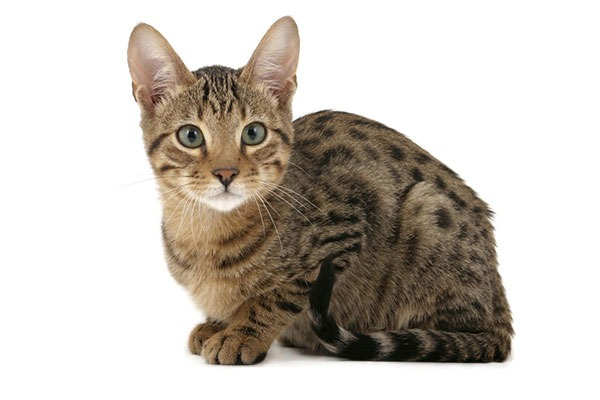

In [11]:
img_bgr = cv.imread("../Images/cat.jpeg", cv.IMREAD_COLOR)
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_RGB2BGR)

Image("../Images/cat.jpeg")

### Addition / Brightness.

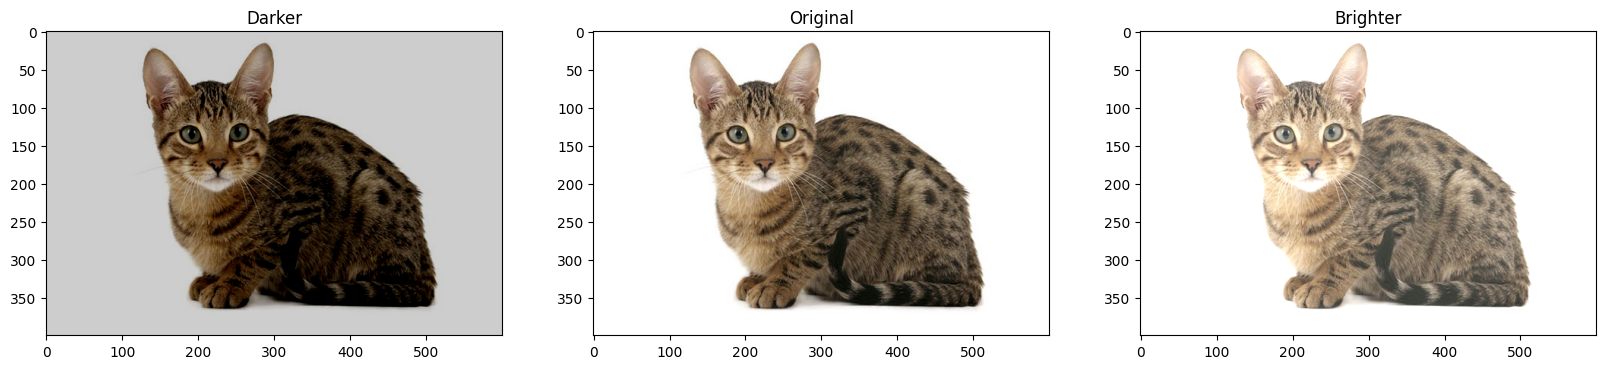

In [14]:
matrix = np.ones(img_rgb.shape, dtype='uint8') * 50

img_rgb_brighter = cv.add(img_rgb, matrix)
img_rgb_darker = cv.subtract(img_rgb, matrix)

plt.figure(figsize=(20, 5))
plt.subplot(131);plt.imshow(img_rgb_darker);plt.title("Darker");
plt.subplot(132);plt.imshow(img_rgb);plt.title("Original");
plt.subplot(133);plt.imshow(img_rgb_brighter);plt.title("Brighter");

### Multiplication / Contrast.

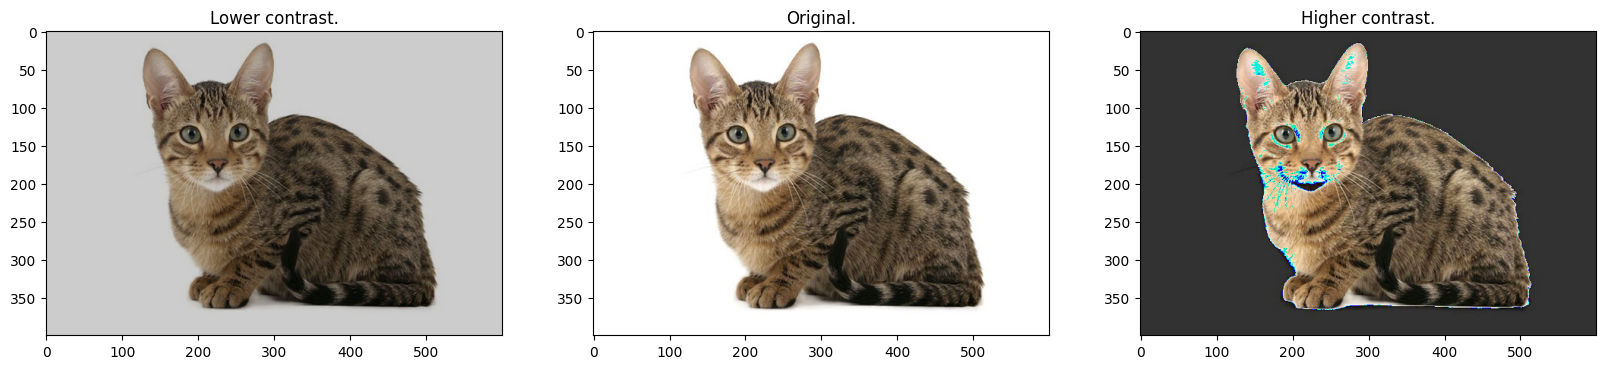

In [17]:
matrix1 = np.ones(img_rgb.shape) * 0.8 
matrix2 = np.ones(img_rgb.shape) * 1.2

img_rgb_darker = np.uint8(cv.multiply(np.float64(img_rgb), matrix1))
img_rgb_brighter = np.uint8(cv.multiply(np.float64(img_rgb), matrix2))

plt.figure(figsize=(20, 5))
plt.subplot(131);plt.imshow(img_rgb_darker);plt.title("Lower contrast.");
plt.subplot(132);plt.imshow(img_rgb);plt.title("Original.");
plt.subplot(133);plt.imshow(img_rgb_brighter);plt.title("Higher contrast.");

- Handling overflow using np.clip.

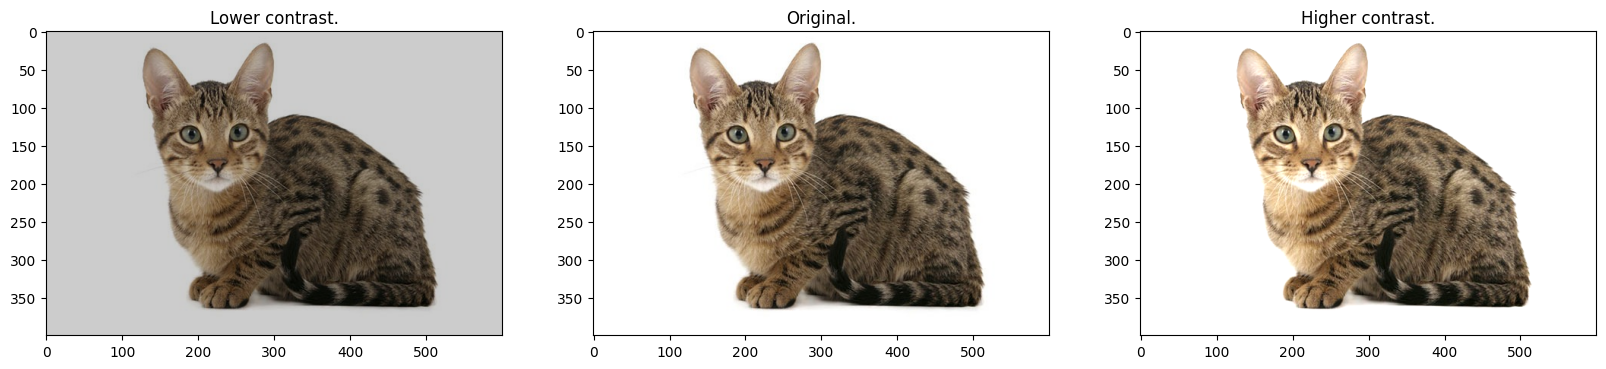

In [21]:
matrix1 = np.ones(img_rgb.shape) * 0.8 
matrix2 = np.ones(img_rgb.shape) * 1.2

img_rgb_darker = np.uint8(cv.multiply(np.float64(img_rgb), matrix1))
img_rgb_brighter = np.uint8(np.clip(cv.multiply(np.float64(img_rgb), matrix2), 0, 255))

plt.figure(figsize=(20, 5))
plt.subplot(131);plt.imshow(img_rgb_darker);plt.title("Lower contrast.");
plt.subplot(132);plt.imshow(img_rgb);plt.title("Original.");
plt.subplot(133);plt.imshow(img_rgb_brighter);plt.title("Higher contrast.");

#### Image Thresholding.--> creates binary images from grayscale images.
- retval, dst = cv2.threshold(src, thresh, maxval, type[, dist])

- Adaptive.
    - dst = cv.adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, c[, dist] )

(400, 600)


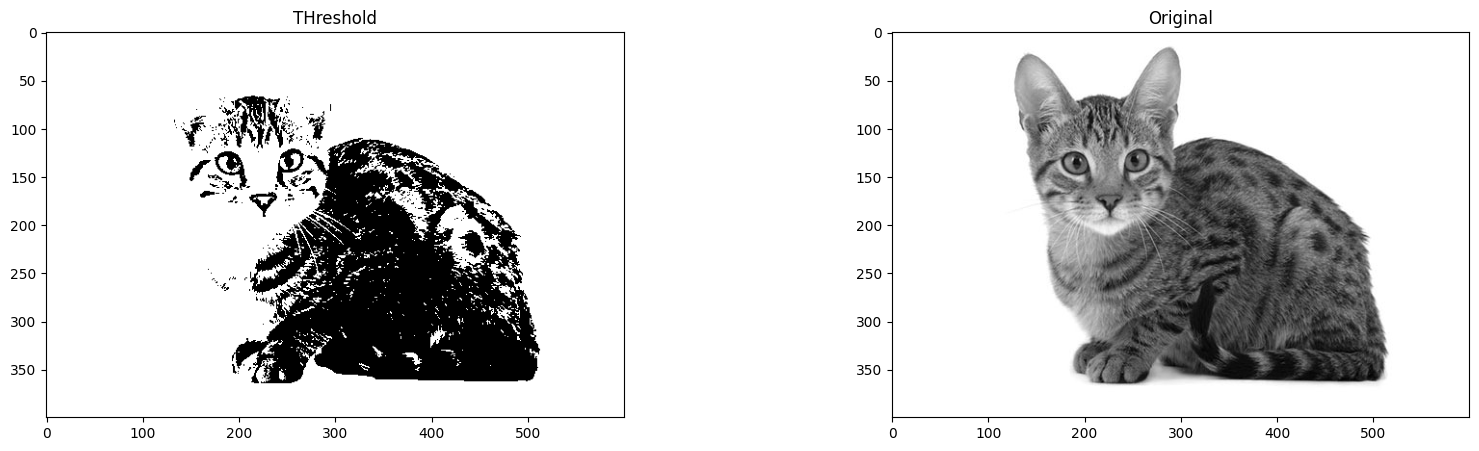

In [29]:
img = cv.imread("../Images/cat.jpeg", cv.IMREAD_GRAYSCALE)
retval, img_thresh = cv.threshold(img, 100, 255, cv.THRESH_BINARY)

plt.figure(figsize=(20, 5))
plt.subplot(121);plt.imshow(img_thresh, cmap="gray");plt.title("Threshold");
plt.subplot(122);plt.imshow(img, cmap="gray");plt.title("Original")

print(img_thresh.shape)

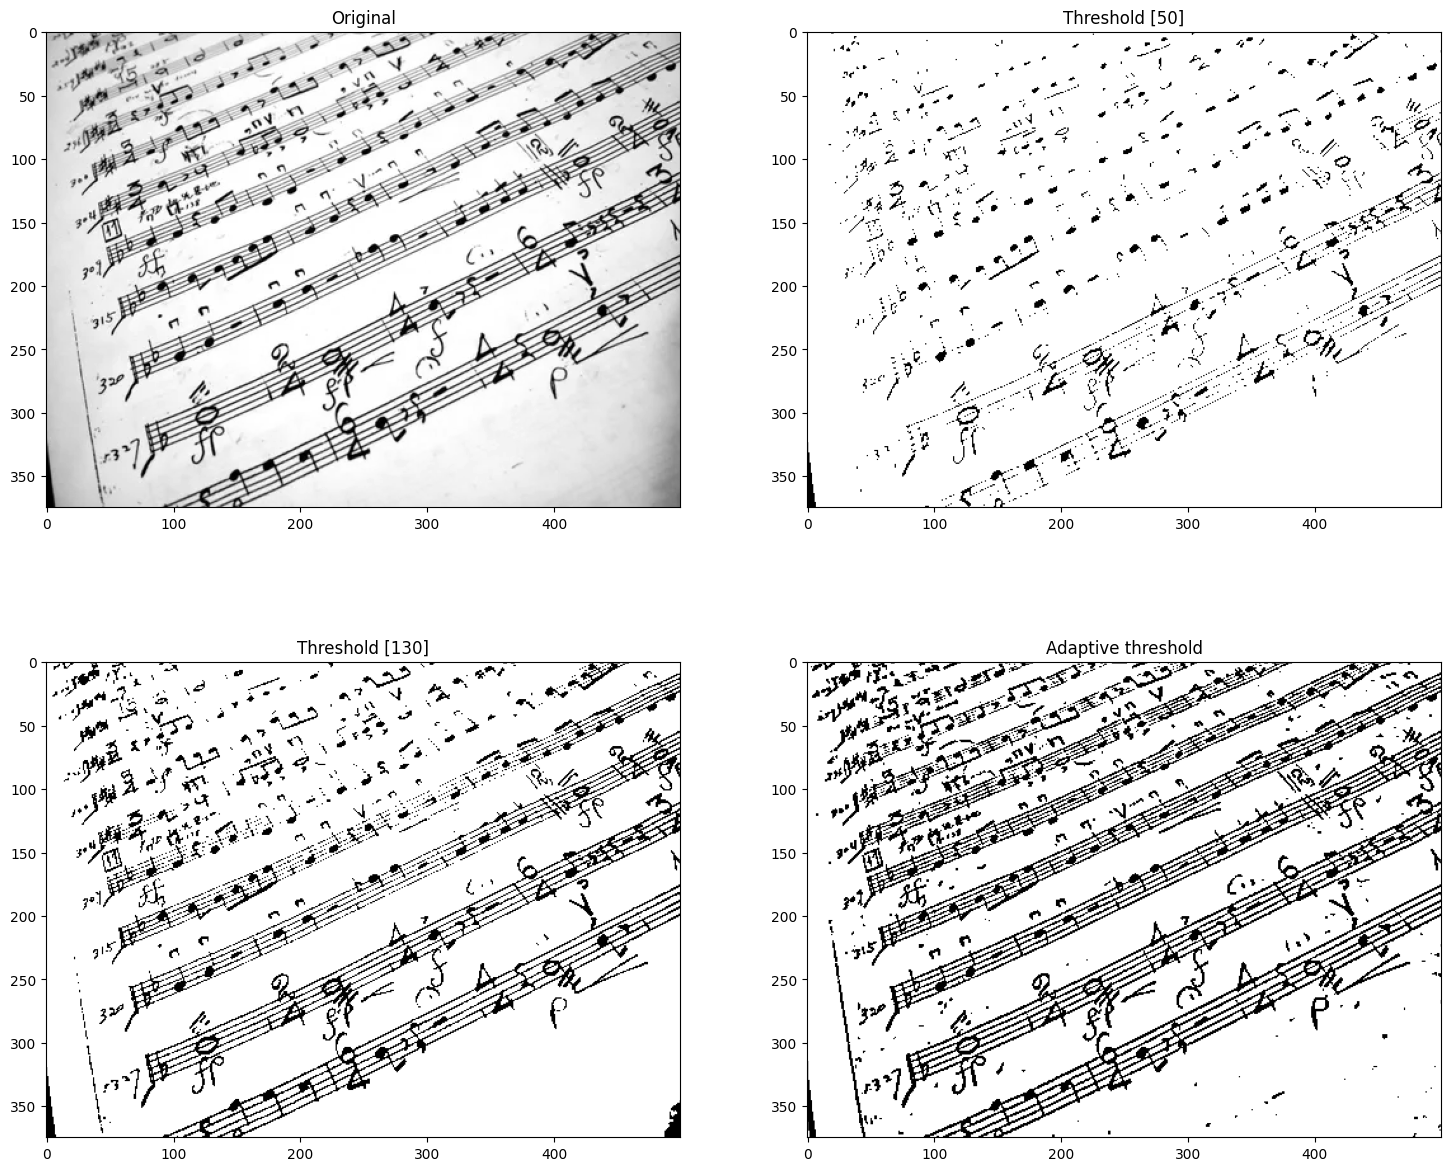

In [38]:
img_note = cv.imread("../Images/note.png", cv.IMREAD_GRAYSCALE)

retval, img_thresh1 = cv.threshold(img_note, 50, 255, cv.THRESH_BINARY)
retval, img_thresh2 = cv.threshold(img_note, 130, 255, cv.THRESH_BINARY)

#Adaptive thresholding.
img_thresh_adap = cv.adaptiveThreshold(img_note, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 11, 7)

plt.figure(figsize=(18, 15))
plt.subplot(221);plt.imshow(img_note, cmap="gray");plt.title("Original");
plt.subplot(222);plt.imshow(img_thresh1, cmap="gray");plt.title("Threshold [50]");
plt.subplot(223);plt.imshow(img_thresh2, cmap="gray");plt.title("Threshold [130]");
plt.subplot(224);plt.imshow(img_thresh_adap, cmap="gray");plt.title("Adaptive threshold");

#### Bitwise Operations. (cv2.bitwise_and(), cv2.bitwise_or(), cv2.bitwise_xor(), cv2.bitwise_not()).
- dst = cv2.bitwise_and(src1, src2[, dist[, mask]])

##### Application: logo manipulation.

(625, 500, 3)


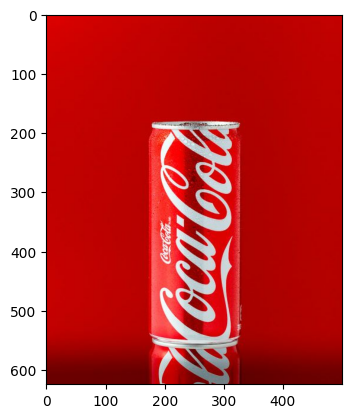

In [84]:
cola_bgr = cv.imread("../Images/coca.jpg")
cola_rgb = cv.cvtColor(cola_bgr, cv.COLOR_BGR2RGB)
print(cola_rgb.shape)
logo_w = cola_rgb.shape[0]
logo_h = cola_rgb.shape[1]
plt.imshow(cola_rgb)

(625, 500, 3)


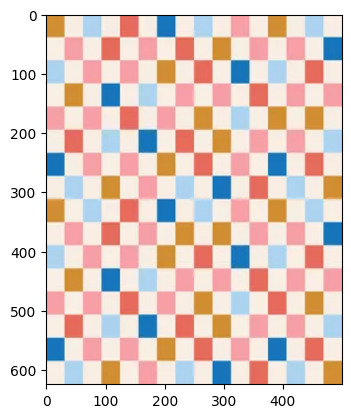

In [85]:
check = cv.imread("../Images/checkboard.jpg")
check_rgb = cv.cvtColor(check, cv.COLOR_BGR2RGB)

aspect_ratio = logo_w / check_rgb.shape[1]
dim = (logo_h, int(check_rgb.shape[0] * aspect_ratio))

check_rgb = cv.resize(check_rgb, dim, interpolation=cv.INTER_AREA)

plt.imshow(check_rgb)
print(check_rgb.shape)

- Create mask for original image.

(625, 500)


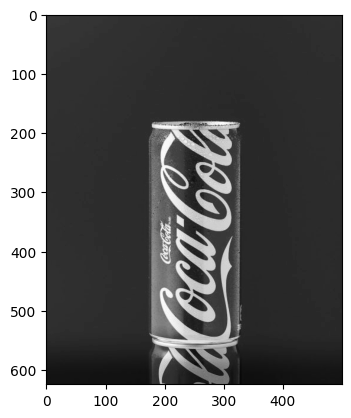

In [97]:
cola_gray = cv.cvtColor(cola_rgb, cv.COLOR_RGB2GRAY)

retval, cola_mask =  cv.threshold(cola_gray, 150, 255, cv.THRESH_BINARY)
plt.imshow(cola_gray, cmap="gray")
print(cola_gray.shape)

- Invert the mask.

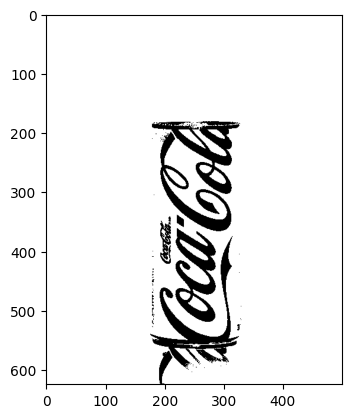

In [98]:
cola_mask_inv = cv.bitwise_not(cola_mask)
plt.imshow(cola_mask_inv, cmap="gray")

- apply check on the mask.

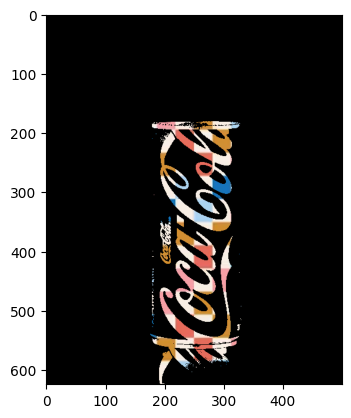

In [99]:
cola_back = cv.bitwise_and(check_rgb, check_rgb, mask=cola_mask)
plt.imshow(cola_back)

- Isolate foreground from image.

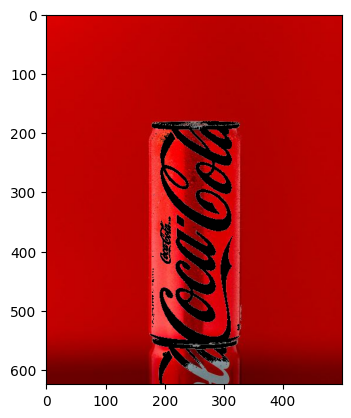

In [100]:
cola_fore = cv.bitwise_and(cola_rgb, cola_rgb, mask=cola_mask_inv)
plt.imshow(cola_fore)

- Merge the background to the foreground.

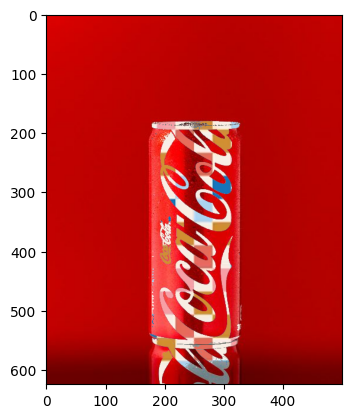

In [101]:
logo = cv.add(cola_back, cola_fore)
plt.imshow(logo)